In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Modèle de Lotka-Volterra et Méthode d'Euler

Considérons un système dynamique décrit par les équations différentielles du modèle de Lotka-Volterra, où \( F(t) \) représente la population de proies et \( P(t) \) celle des prédateurs :  


$\frac{dF}{dt} = \alpha F - \beta F P$
  
$\frac{dP}{dt} = -\nu P + \gamma F P$

Les paramètres \(\alpha\), \(\beta\), \(\nu\), et \(\gamma\) contrôlent les taux d'interaction entre les populations. Nous utilisons la **méthode d'Euler explicite** pour approximer les solutions, avec un pas de temps \( dt \).

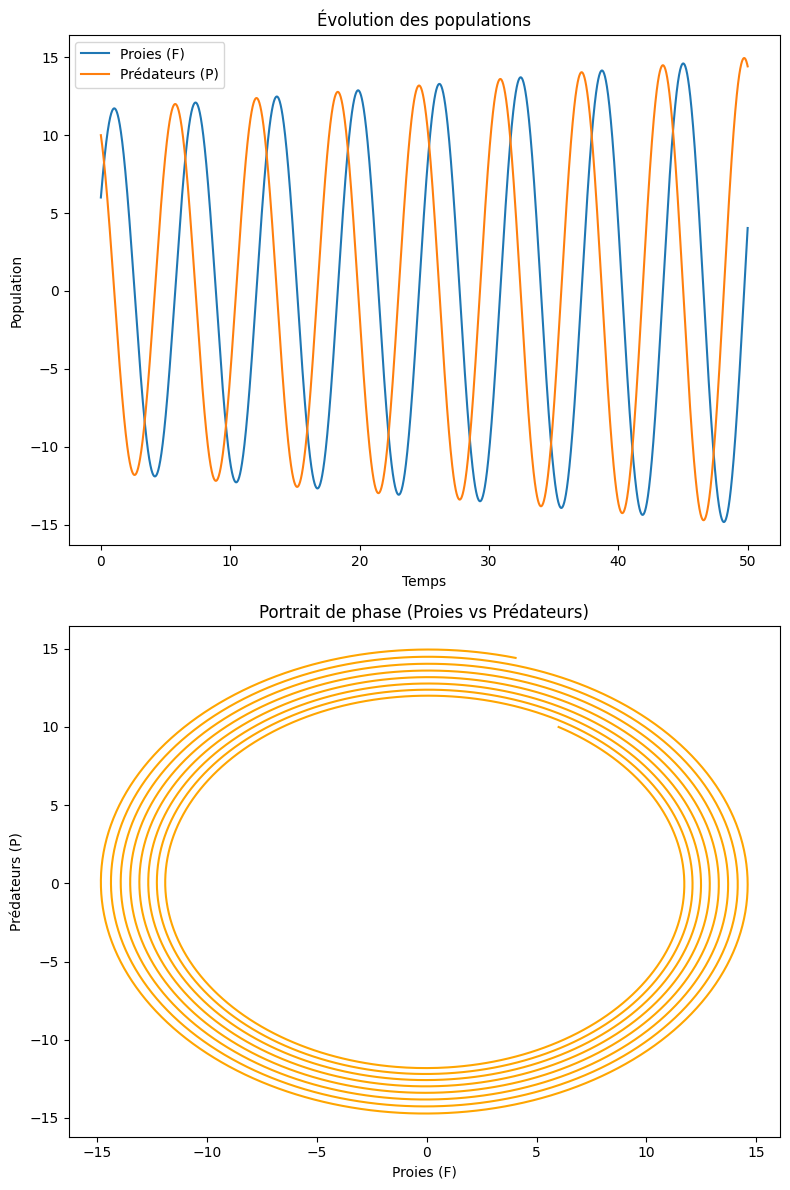

In [3]:
K = 1
alpha = 2
t0 = 0
tf = 50
dt = 0.01
y0 = 0.5
C0 = (y0 - K) / y0
beta = 2
nu = 3
gamma = 1.5
F0 = 6
P0 = 10

# Fonction logistique
def logistic(y, t):
    return alpha * y * (K - y)

# Solution analytique pour la logistique
def f(t):
    t = np.asarray(t) # Assurer la compatibilité avec des vecteurs
    return K / (1 - C0 * np.exp(-alpha * K * t))

def periodique(X,P):
    return P,-X
def f1(X,P):
    return(X^2+P^2)
# Modèle de Volterra
def Volterra(F, P):
    dF = alpha * F - beta * F * P
    dP = -nu * P + gamma * F * P
    return dF, dP

# Méthode d'Euler pour une dimension
def Euler(f, y0, t0, tf, dt):
    n = int((tf - t0) / dt)
    Y = np.zeros(n + 1)
    Y[0] = y0
    t = t0
    for i in range(n):
        Y[i + 1] = Y[i] + dt * f(Y[i], t)
        t += dt
    return Y

# Méthode d'Euler pour deux dimensions
def Euler2D(f, y0, t0, tf, dt):
    n = int((tf - t0) / dt)
    Y = np.zeros((n + 1, 2)) # Matrice pour stocker F et P
    Y[0, :] = y0
    t = t0
    for i in range(n):
        dF, dP = f(Y[i, 0], Y[i, 1]) # Appliquer la fonction Volterra
        Y[i + 1, 0] = Y[i, 0] + dt * dF # Mise à jour de F
        Y[i + 1, 1] = Y[i, 1] + dt * dP # Mise à jour de P
        t += dt
    return Y

# Calcul des temps
time = [t0 + i * dt for i in range(int((tf - t0) / dt) + 1)]

# Résolution du système de Volterra avec Euler2D
result = Euler2D(periodique, [F0, P0], t0, tf, dt)

# Création des graphiques
fig, ax = plt.subplots(2, 1, figsize=(8, 12))

# Graphique 1 : Évolution des populations
ax[0].plot(time, result[:, 0], label="Proies (F)")
ax[0].plot(time, result[:, 1], label="Prédateurs (P)")
ax[0].set_xlabel('Temps')
ax[0].set_ylabel('Population')
ax[0].legend()
ax[0].set_title('Évolution des populations')

# Graphique 2 : Portrait de phase
ax[1].plot(result[:, 0], result[:, 1], color='orange')
ax[1].set_xlabel('Proies (F)')
ax[1].set_ylabel('Prédateurs (P)')
ax[1].set_title('Portrait de phase (Proies vs Prédateurs)')

plt.tight_layout()
plt.show()

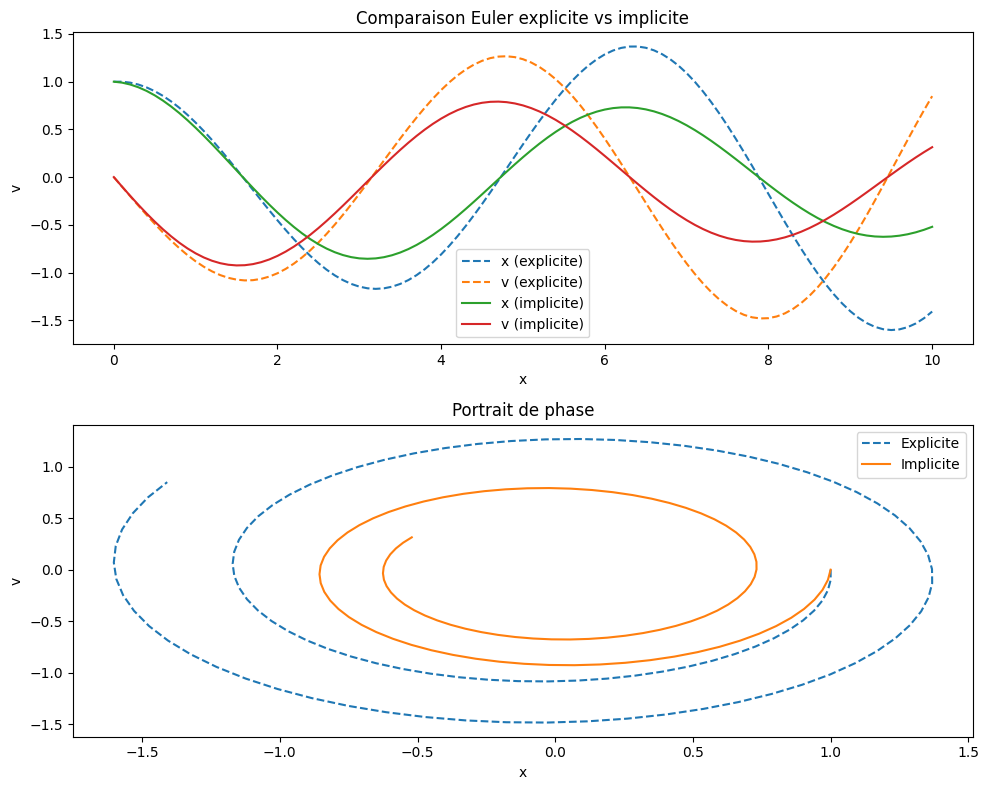

In [4]:
# Paramètres
dt = 0.1  # Pas de temps
t0, tf = 0, 10  # Intervalle de temps
x0, v0 = 1, 0  # Conditions initiales

# Matrice A
A = np.array([[0, 1], [-1, 0]])

# Matrice I + dt * A
I = np.eye(2)  # Matrice identité
M_explicit = I + dt * A  # Schéma explicite
M_implicit = np.linalg.inv(I - dt * A)  # Schéma implicite

# Initialisation des vecteurs pour stocker les résultats
n_steps = int((tf - t0) / dt) + 1
trajectory_explicit = np.zeros((n_steps, 2))
trajectory_implicit = np.zeros((n_steps, 2))
trajectory_explicit[0] = [x0, v0]
trajectory_implicit[0] = [x0, v0]

# Schéma d'Euler explicite
for n in range(1, n_steps):
    trajectory_explicit[n] = np.dot(M_explicit, trajectory_explicit[n - 1])

# Schéma d'Euler implicite
for n in range(1, n_steps):
    trajectory_implicit[n] = np.dot(M_implicit, trajectory_implicit[n - 1])

# Temps pour les axes
time = np.linspace(t0, tf, n_steps)

# Tracé des résultats
plt.figure(figsize=(10, 8))

# Graphique 1 : Évolution de x et v
plt.subplot(2, 1, 1)
plt.plot(time, trajectory_explicit[:, 0], label='x (explicite)', linestyle='dashed')
plt.plot(time, trajectory_explicit[:, 1], label='v (explicite)', linestyle='dashed')
plt.plot(time, trajectory_implicit[:, 0], label='x (implicite)', linestyle='solid')
plt.plot(time, trajectory_implicit[:, 1], label='v (implicite)', linestyle='solid')
plt.xlabel('x')
plt.ylabel('v')
plt.legend()
plt.title('Comparaison Euler explicite vs implicite')

# Graphique 2 : Portrait de phase (x, v)
plt.subplot(2, 1, 2)
plt.plot(trajectory_explicit[:, 0], trajectory_explicit[:, 1], label='Explicite', linestyle='dashed')
plt.plot(trajectory_implicit[:, 0], trajectory_implicit[:, 1], label='Implicite', linestyle='solid')
plt.xlabel('x')
plt.ylabel('v')
plt.title('Portrait de phase')
plt.legend()

plt.tight_layout()
plt.show()

/var/folders/p8/smxcxk5x7xv_qmc9vg56mr380000gn/T/ipykernel_21679/3564298811.py:49: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


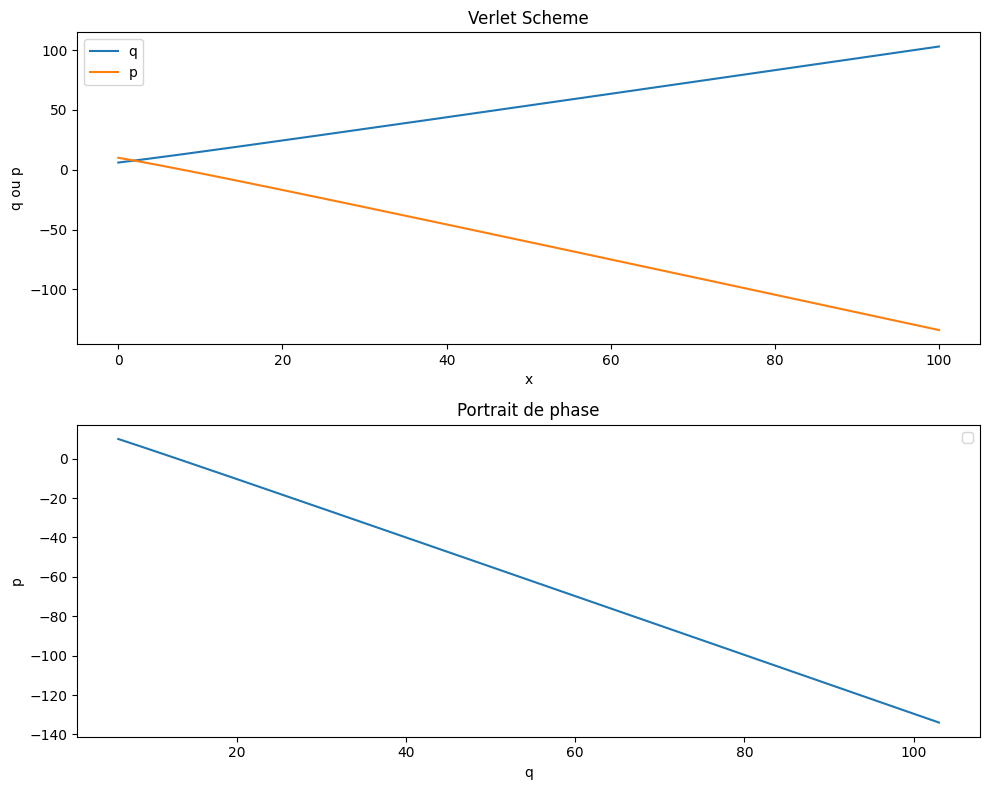

In [5]:
# Paramètres
dt = 0.01  # Pas de temps
t0, tf = 0, 100  # Intervalle de temps
x0, v0 = 6, 10  # Conditions initiales

def Hamiltonian(q,p):
    return (beta*p + gamma*q - alpha*np.log(p) - beta*np.log(q))

def dpH(q,p) : 
    return (beta - alpha/p)

def dqH(q,p):
    return(gamma - beta/q)


# Initialisation des vecteurs pour stocker les résultats
n_steps = int((tf - t0) / dt) + 1
trajectory= np.zeros((n_steps, 2))
trajectory[0] = [x0, v0]

# Schéma de Verlet
for n in range(1, n_steps):
    traj_star = trajectory[n-1][0] + dt/2*dpH(1,trajectory[n-1][1])
    trajectory[n][0] = trajectory[n-1][0] + dt/2*dpH(traj_star,trajectory[n-1][0])
    trajectory[n][1] = trajectory[n-1][1] - dt/2*(dqH(traj_star,1) + dqH(traj_star,1))


# Calcul des temps
time = np.linspace(t0,tf,n_steps)

# Tracé des résultats
plt.figure(figsize=(10, 8))

# Graphique 1 : Évolution de x et v
plt.subplot(2, 1, 1)
plt.plot(time, trajectory[:, 0], label='q', linestyle='solid')
plt.plot(time, trajectory[:, 1], label='p', linestyle='solid')
plt.xlabel('x')
plt.ylabel('q ou p')
plt.legend()
plt.title('Verlet Scheme')

# Graphique 2 : Portrait de phase (x, v)
plt.subplot(2, 1, 2)
plt.plot(trajectory[:, 0], trajectory[:, 1], linestyle='solid')
plt.xlabel('q')
plt.ylabel('p')
plt.title('Portrait de phase')
plt.legend()

plt.tight_layout()
plt.show()

ro = 72.58333333333333


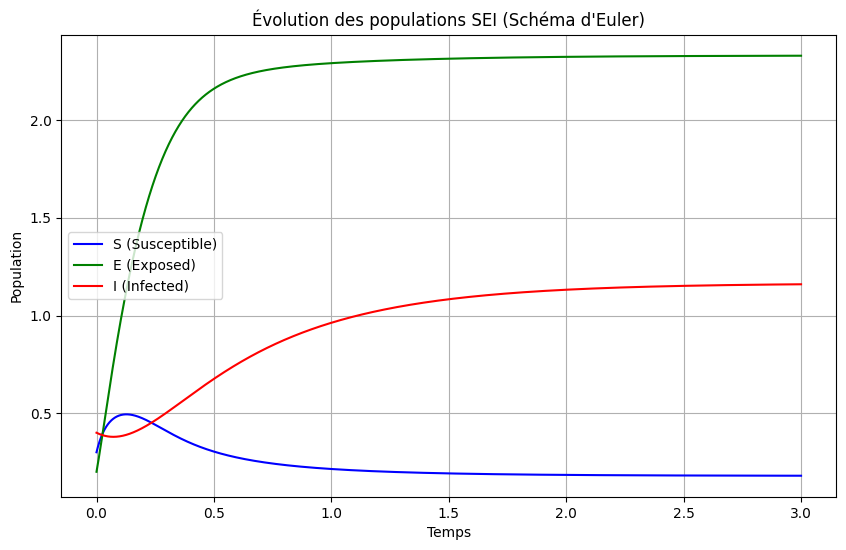

In [6]:
l = 13
gamma = 1
tau = 67
beta = 1
mu = 5
nu = 1
alpha = 1
y0 = [0.3, 0.2, 0.4]
t0 = 0
tf = 3
dt = 0.001
ro = alpha*l*tau/(gamma*(alpha+mu)*(beta+nu))
print('ro =',ro)

def SEI(S,E,I):
    dS = l - gamma*S - tau*I*S + beta*I
    dE = -mu*E - alpha*E + tau*I*S
    dI = -nu*I + alpha*E - beta*I
    return np.array([dS, dE, dI])

# Méthode d'Euler pour trois dimensions
def Euler3D(f, y0, t0, tf, dt):
    n = int((tf - t0) / dt)
    Y = np.zeros((n + 1, 3)) # Matrice pour stocker E, S et I
    Y[0, :] = y0
    t = t0
    for i in range(n):
        dS, dE, dI = f(Y[i, 0], Y[i, 1], Y[i, 2]) # Appliquer la fonction Volterra
        Y[i + 1, 0] = Y[i, 0] + dt * dS # Mise à jour de S
        Y[i + 1, 1] = Y[i, 1] + dt * dE # Mise à jour de E
        Y[i + 1, 2] = Y[i, 2] + dt * dI # Mise à jour de I
        t += dt
    return Y

def Newton(f,df,x0,tol=1e-7,max_iter=100):
    x = x0
    for i in range (max_iter):
        fx = f(x)
        dfx = df(x)
        delta = np.linalg.solve(dfx, -fx)
        xnew = x + delta
        if np.linalg.norm(delta) < tol:
            return xnew
        x = xnew
    raise ValueError("La méthode n'a pas convergé après le nombre maximal d'itérations")

# Jacobienne de SEI
def jacobian_SEI(S, E, I, dt):
    J = np.zeros((3, 3))
    J[0, 0] = -gamma  - tau*I # d(dS)/dS
    J[0, 1] = 0 # d(dS)/dE
    J[0, 2] = -tau * S + beta  # d(dS)/dI

    J[1, 0] = tau*I # d(dE)/dS
    J[1, 1] = -(alpha + mu)  # d(dE)/dE
    J[1, 2] = tau * S  # d(dE)/dI

    J[2, 0] = 0  # d(dI)/dS
    J[2, 1] = alpha  # d(dI)/dE
    J[2, 2] = -nu - beta  # d(dI)/dI

    return np.eye(3) - dt * J  # Jacobienne de G(y_next)

# Méthode d'Euler implicite avec Newton
def EulerImplicitNewton3D(f, y0, t0, tf, dt):
    n = int((tf - t0) / dt)
    Y = np.zeros((n + 1, 3))  # Stockage pour E, S, I
    Y[0, :] = y0  # Condition initiale

    for i in range(n):
        def G(y_next):
            return y_next - Y[i, :] - dt * f(y_next[0], y_next[1], y_next[2])
        
        def J(y_next):
            return jacobian_SEI(y_next[0], y_next[1], y_next[2], dt)
        
        Y[i + 1, :] = Newton(G, J, Y[i, :])
    
    return Y


# Calcul des temps
time = [t0 + i * dt for i in range(int((tf - t0) / dt) + 1)]

# Résolution du système SEI avec Euler3D
result_SEI = EulerImplicitNewton3D(SEI, y0, t0, tf, dt)                  

# Tracé des résultats
plt.figure(figsize=(10, 6))
plt.plot(time, result_SEI[:, 0], label='S (Susceptible)', color='blue')
plt.plot(time, result_SEI[:, 1], label='E (Exposed)', color='green')
plt.plot(time, result_SEI[:, 2], label='I (Infected)', color='red')
plt.xlabel('Temps')
plt.ylabel('Population')
plt.title('Évolution des populations SEI (Schéma d\'Euler)')
plt.legend()
plt.grid()
plt.show()

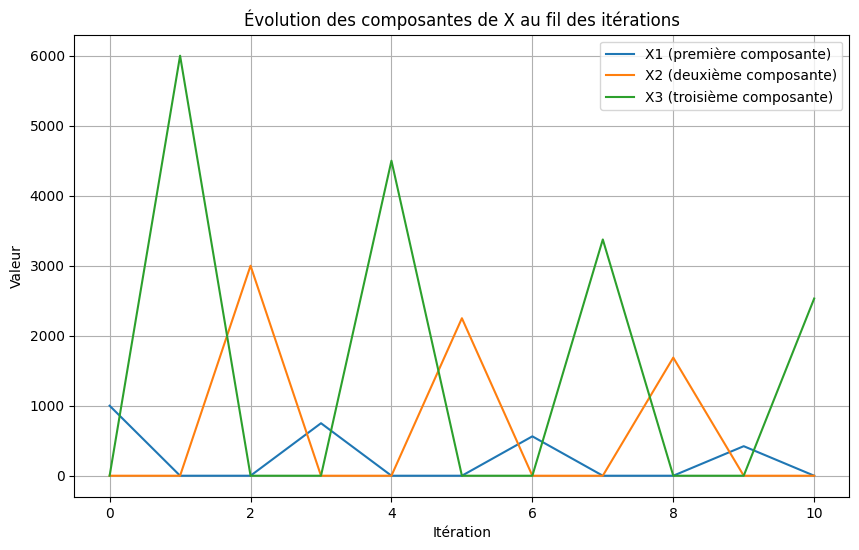

In [7]:
# Définition des paramètres
f1 = 0
f2 = 0
f3 = 6
tau1 = 1/4
tau2 = 1/2
N = 10

# Matrice L
L = np.array([[f1, f2, f3], [tau1, 0, 0], [0, tau2, 0]])

# Initialisation correcte de X
X = np.zeros((N+1, 3)) 
X[0] = [1000, 0, 0]  

# Boucle d'évolution
for i in range(N):  
    X[i+1] = np.dot(X[i], L) 

# Tracé des courbes
plt.figure(figsize=(10, 6))
plt.plot(X[:, 0], label="X1 (première composante)")
plt.plot(X[:, 1], label="X2 (deuxième composante)")
plt.plot(X[:, 2], label="X3 (troisième composante)")
plt.xlabel("Itération")
plt.ylabel("Valeur")
plt.title("Évolution des composantes de X au fil des itérations")
plt.legend()
plt.grid()
plt.show()

Itérations : 74
Valeur propre lambda : 1.0376505453436808
Vecteur propre associé : [0.02026138 0.01946645 0.01873048 0.01801205 0.01730138 0.01660925
 0.01592592 0.01523249 0.01451464 0.01375089]


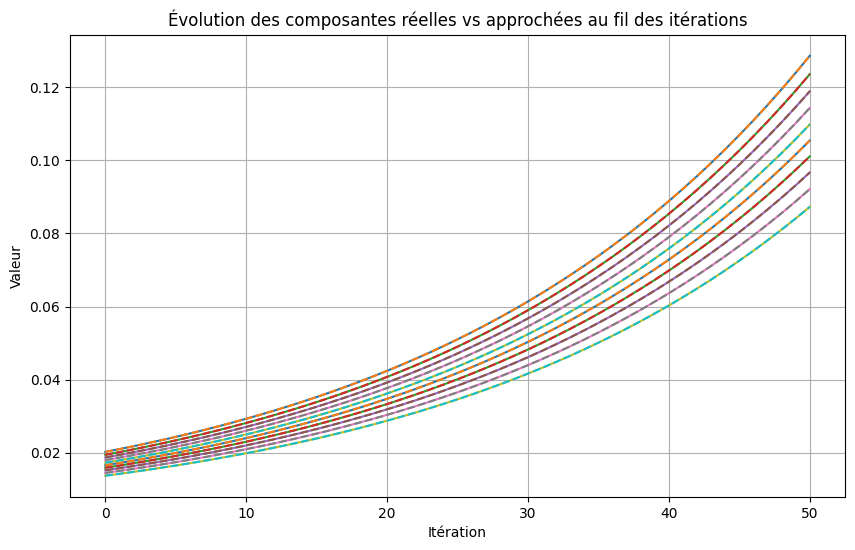

In [8]:
# Données initiales
n = 1000
L = np.array([
    [0, 0.00105, 0.08203, 0.28849, 0.37780, 0.26478, 0.14055, 0.05857, 0.01344, 0.00081],
    [0.99694, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0.99842, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0.99785, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0.99671, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0.99614, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0.99496, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0.99247, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0.98875, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0.98305, 0]
])

Ynew = np.array([4,2,5,9,3,0,8,2,7,1], dtype=float)
Yold = np.ones(10, dtype=float)
psi = np.array([0,0,0,0,1,5,4,12,45,0], dtype=float)
eps = 1e-8
i = 0

# Itération jusqu'à convergence
while (np.linalg.norm(Ynew - Yold) / np.linalg.norm(Yold)) > eps and i < n:
    Yold = Ynew.copy()
    Y1 = np.dot(L, Ynew)
    Y2 = np.dot(Y1, psi)
    Ynew = Y1 / Y2
    i += 1

print('Itérations :', i)
valpropre = np.dot(np.dot(L, Ynew), psi)
print('Valeur propre lambda :', valpropre)
print('Vecteur propre associé :', Ynew)

# Évolution sur plusieurs itérations
Nmax = 50
V = np.zeros((Nmax+1, 10)) 
V[0] = Ynew
X = np.zeros((Nmax+1, 10)) 
X[0] = Ynew

for i in range(Nmax):  
    X[i+1] = np.dot(L, X[i]) 
    V[i+1] = valpropre * V[i]

# Tracé des courbes
plt.figure(figsize=(10, 6))
for j in range(10):
    plt.plot(X[:, j])
    plt.plot(V[:, j], linestyle='dashed')

plt.xlabel("Itération")
plt.ylabel("Valeur")
plt.title("Évolution des composantes réelles vs approchées au fil des itérations")
plt.grid()
plt.show()

In [9]:
n = 1000
L = np.array([
    [0, 0.00105, 0.08203, 0.28849, 0.37780, 0.26478, 0.14055, 0.05857, 0.01344, 0.00081],
    [0.99694, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0.99842, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0.99785, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0.99671, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0.99614, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0.99496, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0.99247, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0.98875, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0.98305, 0]
])
L = L.T
Ynew = np.array([45,2,57,0,0,0,8,0,7,1])
Yold = np.array([0, 0, 0, 0, 0, 0, 0, 0, 0, 1])
psi = [0,0,0,0,1,5,4,12,45,0]
eps = 10e-3
i = 0
while (np.linalg.norm(Ynew-Yold)/np.linalg.norm(Yold)) > eps or i < n :
    Yold = Ynew
    Y1 = np.dot(L,Ynew)
    Y2 = np.dot(Y1,psi)
    Ynew = Y1/Y2
    i+=1
print('Itérations :' , i)
valpropre = np.dot(np.dot(L,Ynew),psi)
print('Valeur propre lambda :' , valpropre)

Itérations : 1000
Valeur propre lambda : 1.0376505504439673
